In [1]:
# @title pip install(셀 실행 완료까지 기다렸다가 재시작)
# 1) 충돌나는 것들 제거
!pip uninstall -y paddlepaddle paddlepaddle-gpu paddleocr paddlex \
                 langchain langchain-community langchain-core

!apt-get -y install poppler-utils
!pip install paddlepaddle-gpu==2.6.1
!pip install paddleocr==2.7.3

!pip install -U "numpy==1.26.4" pandas requests beautifulsoup4 lxml \
               pdf2image "llama-parse" "pymupdf4llm" "pdfplumber" PyPDF2

Found existing installation: langchain 1.1.2
Uninstalling langchain-1.1.2:
  Successfully uninstalled langchain-1.1.2
Found existing installation: langchain-core 1.1.1
Uninstalling langchain-core-1.1.1:
  Successfully uninstalled langchain-core-1.1.1
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 2s (122 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02

In [1]:
#@title Import
import os, json, time, csv, re, requests, difflib, PyPDF2, glob, base64, fitz, asyncio
from typing import List, Dict, Any
from PIL import Image, ImageDraw
from itertools import product
import pandas as pd
import numpy as np
from collections import Counter
from bs4 import BeautifulSoup
from google.colab import userdata
from openai import OpenAI, AsyncOpenAI
from tqdm import tqdm
from pdf2image import convert_from_path
from paddleocr import PaddleOCR
from llama_parse import LlamaParse
import pymupdf4llm, pdfplumber

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

UPSTAGE_API_KEY = userdata.get("UPSTAGE_API_KEY")
LLAMA_CLOUD_API_KEY = userdata.get("LLAMA_CLOUD_API_KEY")
OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")

def ensure_dir(path: str) -> str:
    os.makedirs(path, exist_ok=True)
    return path

def normalize_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text or "").strip()

def normalize_number(text: str) -> str:
    return re.sub(r"[^\d]", "", text or "")

def get_pdf_info(pdf_path: str):
    basename = os.path.splitext(os.path.basename(pdf_path))[0]
    file_type = "image" if "image" in basename.lower() else "text"
    return basename, file_type

OUTPUT_ROOT = "/content/drive/MyDrive/ocr_eval"

# 폴더 경로
sample_dir = ensure_dir(os.path.join(OUTPUT_ROOT, 'SAMPLE')) # 원본 pdf
results_dir = ensure_dir(os.path.join(OUTPUT_ROOT, 'Results'))
llam_path = ensure_dir(os.path.join(results_dir,'llamaparse'))
output_image_dir = ensure_dir(os.path.join(OUTPUT_ROOT, 'IMAGE')) # 스플릿된 이미지 pdf
output_text_dir = ensure_dir(os.path.join(OUTPUT_ROOT, 'TEXT'))   # 스플릿된 텍스트 pdf

# 샘플 파일 경로
input_image_path = os.path.join(sample_dir, "Image_pdf.pdf")
input_text_path = os.path.join(sample_dir, "text_pdf.pdf")

# 스플릿 파일 경로
output_image_path = os.path.join(output_image_dir, "split_image_test.pdf")
output_text_path = os.path.join(output_text_dir, "split_text_test.pdf")

# 스플릿 페이지
text_pdf_pages = np.array([3, 18, 30, 54, 62, 88]) - 1
image_pdf_pages = np.array([13, 14, 15, 16,18,20, 23,25,26,27,54,66,67,68,76, 84,95]) - 1

SAMPLE_PDF_PATH_LIST = [output_image_path,output_text_path]


Consider using the pymupdf_layout package for a greatly improved page layout analysis.


In [ ]:
#@title PDF 자르기

def extract_pages_to_pdf(
    input_pdf_path: str,
    pages_to_extract: np.ndarray,
    output_pdf_path: str,
    sample_type: str
) -> None:
    print(f"{sample_type} 샘플 PDF 생성: '{input_pdf_path}' 에서 페이지 추출 중...")
    try:
        reader = PyPDF2.PdfReader(input_pdf_path)
        writer = PyPDF2.PdfWriter()
        num_pages = len(reader.pages)

        added_pages_count = 0
        for p in pages_to_extract:
            if 0 <= p < num_pages:
                writer.add_page(reader.pages[int(p)])
                added_pages_count += 1
            else:
                print(f"주의: {p+1}페이지({sample_type} 샘플용)는 전체 페이지 수({num_pages})를 초과하거나 유효하지 않아 제외되었습니다. (파일: {pdf_basename(input_pdf_path)})")

        if added_pages_count > 0:
            with open(output_pdf_path, "wb") as f:
                writer.write(f)
            print(f"성공: {sample_type} 샘플 '{output_pdf_path}' 파일이 생성되었습니다.")
        else:
            print(f"정보: '{input_pdf_path}'에서 {sample_type} 샘플로 추출할 유효한 페이지가 없어 파일이 생성되지 않았습니다.")
    except FileNotFoundError:
        print(f"오류: {sample_type} 샘플 원본 PDF 파일 '{input_pdf_path}'를 찾을 수 없습니다. 경로를 확인해 주세요.")
    except Exception as e:
        print(f"{sample_type} 샘플 PDF 생성 중 오류 발생: {e}")

# 샘플 PDF 생성
extract_pages_to_pdf(input_text_path, text_pdf_pages, output_text_path, "텍스트")
extract_pages_to_pdf(input_image_path, image_pdf_pages, output_image_path, "이미지")

텍스트 샘플 PDF 생성: '/content/drive/MyDrive/ocr_eval/SAMPLE/text_pdf.pdf' 에서 페이지 추출 중...
성공: 텍스트 샘플 '/content/drive/MyDrive/ocr_eval/TEXT/split_text_test.pdf' 파일이 생성되었습니다.
이미지 샘플 PDF 생성: '/content/drive/MyDrive/ocr_eval/SAMPLE/Image_pdf.pdf' 에서 페이지 추출 중...
성공: 이미지 샘플 '/content/drive/MyDrive/ocr_eval/IMAGE/split_image_test.pdf' 파일이 생성되었습니다.


In [ ]:
#@title upstage 파서
def run_upstage_full_process(pdf_path: str) -> None:
    # 원본 파일 이름, 파일 타입 추출
    name, file_type = get_pdf_info(pdf_path)

    # 원본 PDF 폴더에 하위 폴더(upstage) 생성
    parent_dir = os.path.dirname(pdf_path)
    upstage_dir = ensure_dir(os.path.join(parent_dir, "upstage"))

    # Root 디렉토리에 Results 폴더 생성
    results_dir = ensure_dir(os.path.join(OUTPUT_ROOT, "Results"))
    target_filename = f"upstage_{file_type}.jsonl"
    target_path = os.path.join(results_dir, target_filename)

    # ======================================
    # 1. API 호출
    # ======================================
    url = "https://api.upstage.ai/v1/document-ai/document-parse"
    headers = {"Authorization": f"Bearer {UPSTAGE_API_KEY}"}
    payload = {
        "ocr": "force",             # 'auto': 텍스트가 없으면 OCR / 'force' : 무조건 OCR
        "output_formats": "html",   # 결과 포맷 ( html / markdown / text )
        "coordinates": True         # 좌표 정보 받기 (박스 그리기용)
    }
    start = time.time()

    print(f"[{name}] Upstage 실행 중... (Type: {file_type})")
    try:
        with open(pdf_path, "rb") as f:
            resp = requests.post(url,
                                 headers=headers,
                                 files={"document": f},
                                 data=payload,
                                 timeout=300)
    except Exception as e:
        print(f"[{name}] 요청 에러: {e}")
        return

    elapsed = time.time() - start
    if resp.status_code != 200:
        print(f"[{name}] API 실패: {resp.status_code}")
        return

    result = resp.json()
    elements = result.get("elements", [])

    # ======================================
    # 2. PDF -> 이미지 변환 및 박스 그리기
    # ======================================
    print(f"   -> 시각화 이미지 생성 중... ({upstage_dir})")
    try:
        # PDF를 이미지 리스트로 변환
        images = convert_from_path(pdf_path)

        for i, image in enumerate(images):
            page_num = i + 1
            width, height = image.size
            draw = ImageDraw.Draw(image)

            # 현재 페이지 요소만 필터링
            page_elements = [e for e in elements if e.get("page") == page_num]

            for elem in page_elements:
                coords = elem.get("coordinates") # 비율 좌표 (0.0 ~ 1.0)
                category = elem.get("category", "")

                if coords and len(coords) >= 4:
                    # 비율 좌표 -> 픽셀 좌표 변환
                    points = []
                    for point in coords:
                        px = point.get("x", 0) * width
                        py = point.get("y", 0) * height
                        points.append((px, py))

                    # 카테고리별 색상 (표: 파랑, 그림: 초록, 글자: 빨강)
                    if category == "table":
                        color = "blue"
                        line_w = 3
                    elif category in ["figure", "image", "chart"]:
                        color = "green"
                        line_w = 3
                    else:
                        color = "red"
                        line_w = 2

                    # 박스 그리기
                    draw.polygon(points, outline=color, width=line_w)

            # 이미지 파일 저장 (예: split_test_p001.png)
            img_save_path = os.path.join(upstage_dir, f"{name}_p{page_num:03d}.png")
            image.save(img_save_path)

    except Exception as e:
        print(f"⚠️ 시각화 이미지 생성 실패: {e}")

    # ======================================
    # 3. HTML 저장 (Upstage 폴더)
    # ======================================
    content_raw = result.get("content", {})
    html = ""
    if isinstance(content_raw, dict):
        html = content_raw.get("html", "")
    elif isinstance(content_raw, str):
        html = content_raw
    if not html:
        html = result.get("html", "")

    html_path = os.path.join(upstage_dir, f"{name}.html")
    with open(html_path, "w", encoding="utf-8") as f:
        f.write(html)

    # ======================================
    # 4. JSONL 저장 (Results 폴더)
    # ======================================
    pages_text_data = {}

    # 데이터 수집
    if elements:
        for elem in elements:
            page_num = elem.get("page", 1)

            # 텍스트 추출 (우선순위: text -> content.text -> content.html -> content str)
            text = elem.get("text")
            if not text:
                content = elem.get("content")
                if isinstance(content, dict):
                    text = content.get("text") or content.get("html", "")
                elif isinstance(content, str):
                    text = content

            # 태그 제거
            if text and "<" in text and ">" in text:
                try: text = BeautifulSoup(text, "html.parser").get_text(" ", strip=True)
                except: pass

            if text and text.strip():
                pages_text_data.setdefault(page_num, []).append(text.strip())
    else:
        # Fallback (HTML 전체 파싱)
        soup = BeautifulSoup(html, "html.parser")
        pages_text_data[1] = [soup.get_text(" ", strip=True)]

    # 파일 쓰기
    saved_lines = 0
    with open(target_path, "a", encoding="utf-8") as f:
        for page_num in sorted(pages_text_data.keys()):
            full_text = " ".join(pages_text_data[page_num])
            try:
                clean_text = normalize_whitespace(full_text)
            except:
                clean_text = full_text.strip()

            rec = {
                "pdf_name": name,
                "type": file_type,
                "parser": "upstage",
                "page_index": page_num,
                "text": clean_text
            }
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
            saved_lines += 1


    print(f"[{name}] 최종 완료 ({elapsed:.2f}s)")
    print(f"   - 시각화/HTML: {upstage_dir}")
    print(f"   - JSONL 데이터: {target_path} ({saved_lines}페이지)")

# 실행 루프
for pdf_path in SAMPLE_PDF_PATH_LIST:
    run_upstage_full_process(pdf_path)

[split_image_test] Upstage 실행 중... (Type: image)
   -> 시각화 이미지 생성 중... (/content/drive/MyDrive/ocr_eval/IMAGE/upstage)
[split_image_test] 최종 완료 (1.31s)
   - 시각화/HTML: /content/drive/MyDrive/ocr_eval/IMAGE/upstage
   - JSONL 데이터: /content/drive/MyDrive/ocr_eval/Results/upstage_image.jsonl (17페이지)
[split_text_test] Upstage 실행 중... (Type: text)
   -> 시각화 이미지 생성 중... (/content/drive/MyDrive/ocr_eval/TEXT/upstage)
[split_text_test] 최종 완료 (0.88s)
   - 시각화/HTML: /content/drive/MyDrive/ocr_eval/TEXT/upstage
   - JSONL 데이터: /content/drive/MyDrive/ocr_eval/Results/upstage_text.jsonl (6페이지)


In [ ]:
#@title llamaparse 파서
# 파서 docs https://developers.llamaindex.ai/python/cloud/llamaparse/features/parsing_options/
# https://developers.llamaindex.ai/python/framework/module_guides/loading/simpledirectoryreader

def run_llamaparse_and_save(pdf_path: str) -> None:
    # 1. 원본 파일 이름, 파일 타입 추출 (image / text)
    name, file_type = get_pdf_info(pdf_path)
    parent_dir = os.path.dirname(pdf_path)
    llama_dir = ensure_dir(os.path.join(parent_dir, "llamaparse"))

    print(f"[{name}] LlamaParse 실행 중... (Type: {file_type})")

    # 이미지 타입만 Premium 모드 사용
    use_premium = True if file_type == "image" else False
    start = time.time()

    # 2. LlamaParse 초기화 및 실행
    try:
        parser = LlamaParse(
            result_type="markdown",  # 'text' or 'markdown'
            language="ko",           # 한국어 설정
            verbose=True,
            api_key=LLAMA_CLOUD_API_KEY,
            premium_mode=use_premium,   # 프리미엄 모드
            skip_diagonal_text=True,    # 워터마크 제거
            output_tables_as_HTML=False,# 표를 HTML 형식으로 추출
            preserve_layout_alignment_across_pages=False,  # 페이지 바뀌면서 표가 어그러지는 거 막아줌
            merge_tables_across_pages_in_markdown=False,   # 표가 페이지 넘어갈 때(푸터 다 없어짐 조심)
            hide_headers=False,
            hide_footers=False,
            # bounding_box = "0.1,0,0.1,0", # 헤더푸터 안 지워질 때 짤라버리기
            system_prompt_append=(
                "You are parsing Korean university admission guides and "
                "student records. Preserve tables exactly as they appear "
                "Focus on admission quotas, schedules, eligibility, and evaluation criteria."
            ),

        )

        # load_data는 페이지별 Document 객체 리스트를 반환함
        docs = parser.load_data(pdf_path)

    except Exception as e:
        print(f"🚨 [{name}] 파싱 실패: {e}")
        return

    elapsed = time.time() - start


    # 3. 중간 결과 저장 (.md 파일)
    # 각 페이지의 텍스트를 하나로 합쳐서 로컬에 백업
    full_text = "\n\n".join([d.text for d in docs])
    md_path = os.path.join(llama_dir, f"{name}.md")

    with open(md_path, "w", encoding="utf-8") as f:
        f.write(full_text)

    # 4. JSONL 저장 (페이지별 분할)
    jsonl_filename = f"llamaparse_{file_type}.jsonl"
    jsonl_path = os.path.join(results_dir, jsonl_filename)

    saved_count = 0
    with open(jsonl_path, "a", encoding="utf-8") as f:
        for i, doc in enumerate(docs):
            page_text = doc.text or ""

            # 전처리 (함수 없으면 .strip() 사용)
            try:
                clean_text = normalize_whitespace(page_text)
            except NameError:
                clean_text = page_text.strip()

            rec = {
                "pdf_name": name,
                "type": file_type,
                "parser": "llamaparse",
                "page_index": i + 1,
                "text": clean_text
            }
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
            saved_count += 1

    print(f"[{name}] 완료 ({elapsed:.2f}s):")
    print(f"   - Markdown: {md_path}")
    print(f"   - JSONL: {jsonl_path} ({saved_count} pages)")

# 실행 루프
for pdf_path in SAMPLE_PDF_PATH_LIST:
    run_llamaparse_and_save(pdf_path)

[split_image_test] LlamaParse 실행 중... (Type: image)
Started parsing the file under job_id 2063496b-c4af-472e-b988-90573033bd1e
.[split_image_test] 완료 (98.91s):
   - Markdown: /content/drive/MyDrive/ocr_eval/IMAGE/llamaparse/split_image_test.md
   - JSONL: /content/drive/MyDrive/ocr_eval/Results/llamaparse_image.jsonl (17 pages)
[split_text_test] LlamaParse 실행 중... (Type: text)
Started parsing the file under job_id 07ce5fbd-7f45-49e7-bd6a-17c5d4440e4c
.[split_text_test] 완료 (68.82s):
   - Markdown: /content/drive/MyDrive/ocr_eval/TEXT/llamaparse/split_text_test.md
   - JSONL: /content/drive/MyDrive/ocr_eval/Results/llamaparse_text.jsonl (6 pages)


In [ ]:
#@title pymupdf4llm 파서
MAX_CONCURRENT_REQUESTS = 5
OCR_TEXT_THRESHOLD = 50    # 이 길이 이하인 페이지는 이미지 OCR로 처리
aclient = AsyncOpenAI(api_key=OPENAI_API_KEY)
sem = asyncio.Semaphore(MAX_CONCURRENT_REQUESTS)

def encode_image_local(path: str) -> str | None:
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def render_page_base64(doc: fitz.Document, page_idx: int, zoom: float = 2.0) -> str | None:
    page = doc[page_idx]
    pix = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom))
    return base64.b64encode(pix.tobytes("png")).decode("utf-8")

def clean_markdown(text: str) -> str:
    text = re.sub(r'(^#+.*)\n+(?=\|)', r'\1\n', text, flags=re.MULTILINE)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

async def call_gpt_vision_async(base64_img: str) -> str:
    if not base64_img: return ""

    async with sem:
        try:
            resp = await aclient.chat.completions.create(
                model="gpt-4.1-mini",
                messages=[
                    {
                        "role": "system",
                        "content": (
                            "You are the image pdf parser. "
                            "Write all text and tables in the image in markdown form "
                            "without any changes in content. Do not add explanations."
                            "Clearly distinguish between columns and rows according to letter size and color."
                        ),
                    },
                    {
                        "role": "user",
                        "content": [
                            {
                                "type": "image_url",
                                "image_url": {"url": f"data:image/png;base64,{base64_img}"},
                            }
                        ],
                    },
                ],
                temperature=0.0,
            )
            md = resp.choices[0].message.content or ""
            return clean_markdown(md)
        except Exception as e:
            print(f"[Vision Error] {type(e).__name__}: {e}")
            return ""

# -------------------- 메인 로직 --------------------
async def run_pymupdf4llm_process(pdf_path: str) -> None:
    name, file_type = get_pdf_info(pdf_path)
    pdf4llm_dir   = ensure_dir(os.path.join(os.path.dirname(pdf_path), "pymupdf4llm"))
    part_img_dir  = ensure_dir(os.path.join(pdf4llm_dir, "part_img"))
    debug_img_dir = ensure_dir(os.path.join(pdf4llm_dir, "debug_img"))
    pdf4llm_md_path = os.path.join(pdf4llm_dir, f"{name}.md")

    print(f"🚀 [{name}] 하이브리드 파싱 시작")

    # 1. PyMuPDF4LLM 기본 파싱
    pages = pymupdf4llm.to_markdown(
        pdf_path,
        table_strategy="lines_strict",
        page_chunks=True,
        write_images=True,
        image_path=part_img_dir,
        image_format="png"
    )

    # 2. PDF 열기 (FULL OCR + 레이아웃 디버그용)
    doc = fitz.open(pdf_path)

    # FULL / PART OCR 대상 수집
    md_chunks: list[str] = []
    full_jobs: list[tuple[int, asyncio.Task]] = []         # (page_idx, task)
    embed_jobs: list[tuple[int, str, asyncio.Task]] = []   # (page_idx, full_md_tag, task)

    for page_idx, p in enumerate(pages):
        raw_md = p["text"]
        # 이미지 마크다운만 제거한 텍스트 길이로 "진짜 텍스트" 길이 판단
        text_only = re.sub(r'!\[.*?\]\(.*?\)', '', raw_md or '')
        text_only_len = len(text_only.strip())

        page = doc[page_idx]

        # ---------- 레이아웃 디버그 (텍스트/테이블 박스) ----------
        try:
            blocks = page.get_text("dict")["blocks"]
            for block in blocks:
                if block["type"] == 0:  # text
                    page.draw_rect(block["bbox"], color=(1, 0, 1), width=1)  # magenta

            tables = page.find_tables(strategy="text")
            for table in tables:
                page.draw_rect(table.bbox, color=(1, 0, 0), width=2)  # red
                for cell in table.cells:
                    page.draw_rect(cell, color=(0, 0, 1), width=0.5)  # blue

            pix = page.get_pixmap()
            dbg_path = os.path.join(debug_img_dir, f"{file_type}_layout_p{page_idx+1:03d}.png")
            pix.save(dbg_path)
        except Exception as e:
            print(f"   [Layout Warning] p.{page_idx+1}: {e}")

        # ---------- FULL vs PART 분기 ----------
        if text_only_len < OCR_TEXT_THRESHOLD:
            # 페이지 전체가 이미지일 가능성 높음 → FULL OCR
            print(f"   - P.{page_idx+1}: text_only={text_only_len}자 → FULL OCR 대상")
            md_chunks.append("")  # 나중에 Vision 결과로 교체
            b64 = render_page_base64(doc, page_idx, zoom=2.0)
            if b64:
                task = asyncio.create_task(call_gpt_vision_async(b64))
                full_jobs.append((page_idx, task))
        else:
            # 텍스트는 충분히 있고, 일부 이미지만 존재하는 페이지 → PART OCR
            md_chunks.append(raw_md)  # 기본 텍스트 우선 저장
            # 이 페이지 안의 ![](path) 이미지들만 골라 Vision에 보냄
            for m in re.finditer(r'(!\[.*?\]\((.*?)\))', raw_md or ""):
                full_md_tag = m.group(1)   # "![...](path)"
                img_path    = m.group(2)   # path
                # part_img_dir의 파일만 처리 (안전장치)
                if os.path.exists(img_path) and os.path.commonpath([img_path, part_img_dir]) == part_img_dir:
                    b64 = encode_image_local(img_path)
                    if not b64:
                        continue
                    task = asyncio.create_task(call_gpt_vision_async(b64))
                    embed_jobs.append((page_idx, full_md_tag, task))

    # 3. FULL OCR 실행 및 적용
    if full_jobs:
        print(f"   -> FULL OCR {len(full_jobs)}페이지 실행 중...")
        full_results = await asyncio.gather(*[t for _, t in full_jobs])
        for (page_idx, _), md in zip(full_jobs, full_results):
            if md:
                md_chunks[page_idx] = md
            else:
                # Vision 실패 시 기본 PyMuPDF4LLM 텍스트라도 유지
                md_chunks[page_idx] = pages[page_idx]["text"]

    # 4. PART OCR 실행 및 적용 (FULL 처리된 페이지는 여기 안 옴)
    if embed_jobs:
        print(f"   -> PART OCR {len(embed_jobs)}개 이미지 실행 중...")
        embed_results = await asyncio.gather(*[t for _, _, t in embed_jobs])
        for (page_idx, full_md_tag, _), md in zip(embed_jobs, embed_results):
            if not md:
                continue
            # 이미지 마크다운 태그 위치에 Vision 결과 삽입
            md_chunks[page_idx] = md_chunks[page_idx].replace(full_md_tag, f"\n\n{md}\n\n")

    doc.close()

    # 5. 최종 Markdown 저장
    final_md = clean_markdown("\n\n".join(md_chunks))
    with open(pdf4llm_md_path, "w", encoding="utf-8") as f:
        f.write(final_md)

    print(f"✅ [{name}] 완료 → {pdf4llm_md_path}")

    # ======================================
    # 6. JSONL 저장
    # ======================================
    jsonl_filename = f"pymupdf4llm_{file_type}.jsonl"
    jsonl_path = os.path.join(results_dir, jsonl_filename)

    with open(jsonl_path, "a", encoding="utf-8") as f:
        for page_idx, md_page in enumerate(md_chunks, start=1):
            raw_text = md_page or ""

            text_no_html = re.sub(r'<br\s*/?>', ' ', raw_text, flags=re.IGNORECASE)
            text_plain   = re.sub(r'[\|\-\*\[\]\(\)\#]', ' ', text_no_html)

            try:
                clean_text = normalize_whitespace(text_plain)
            except Exception:
                clean_text = text_plain.strip()

            rec = {
                "pdf_name": name,
                "type": file_type,
                "parser": "pymupdf4llm",
                "page_index": page_idx,
                "text": clean_text,
            }
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
    print(f'{jsonl_path}에 결과 저장 완료')

# 실행 예시
async def main():
    for pdf_path in SAMPLE_PDF_PATH_LIST:
        await run_pymupdf4llm_process(pdf_path)

await main()

🚀 [split_image_test] 하이브리드 파싱 시작
   - P.1: text_only=0자 → FULL OCR 대상
   - P.2: text_only=0자 → FULL OCR 대상
   - P.3: text_only=0자 → FULL OCR 대상
   - P.4: text_only=0자 → FULL OCR 대상
   - P.5: text_only=0자 → FULL OCR 대상
   - P.6: text_only=0자 → FULL OCR 대상
   - P.7: text_only=0자 → FULL OCR 대상
   - P.8: text_only=0자 → FULL OCR 대상
   - P.9: text_only=0자 → FULL OCR 대상
   - P.10: text_only=0자 → FULL OCR 대상
   - P.11: text_only=0자 → FULL OCR 대상
   - P.12: text_only=0자 → FULL OCR 대상
   - P.13: text_only=0자 → FULL OCR 대상
   - P.14: text_only=0자 → FULL OCR 대상
   - P.15: text_only=0자 → FULL OCR 대상
   - P.16: text_only=0자 → FULL OCR 대상
   - P.17: text_only=0자 → FULL OCR 대상
   -> FULL OCR 17페이지 실행 중...
✅ [split_image_test] 완료 → /content/drive/MyDrive/ocr_eval/IMAGE/pymupdf4llm/split_image_test.md
/content/drive/MyDrive/ocr_eval/Results/pymupdf4llm_image.jsonl에 결과 저장 완료
🚀 [split_text_test] 하이브리드 파싱 시작
✅ [split_text_test] 완료 → /content/drive/MyDrive/ocr_eval/TEXT/pymupdf4llm/split_text_test.md
/conte

In [ ]:
#@title pdfplumber 파서
def run_pdfplumber_and_save(pdf_path: str) -> None:
    name, file_type = get_pdf_info(pdf_path) # 원본 파일 이름, 타입 추출
    parent_dir = os.path.dirname(pdf_path)
    save_dir = ensure_dir(os.path.join(parent_dir, "pdfplumber")) # 저장소 위치

    print(f"[{name}] 처리 시작... (저장 위치: {save_dir})")

    extracted_pages = []

    try:
        with pdfplumber.open(pdf_path) as pdf:
            for i, page in enumerate(pdf.pages):
                # ---------------------------------------------------------
                # A. 시각화 (레이아웃 박스 그리기)
                # ---------------------------------------------------------
                # 1. 페이지를 이미지로 변환 (해상도 150이면 충분, 300은 너무 느림)
                im = page.to_image(resolution=200)

                # 2. [빨간색] 텍스트(단어) 인식 영역 그리기
                im.draw_rects(page.extract_words(), stroke="red", stroke_width=2)

                # 3. [파란색] 표(Table) 인식 영역 그리기
                tables = page.find_tables()
                if tables:
                    for table in tables:
                        # 표의 각 셀(Cell)마다 박스 그리기
                        im.draw_rects(table.cells, stroke="blue", stroke_width=3, fill=None)

                # 4. 이미지 저장 (split_text_test_p001_debug.png)
                img_filename = f"{name}_p{i+1:03d}_debug.png"
                img_path = os.path.join(save_dir, img_filename)
                im.save(img_path, format="PNG")

                # ---------------------------------------------------------
                # B. 텍스트 추출 (Raw Text)
                # ---------------------------------------------------------
                # 불필요한 마크다운 변환 제거, 순수 텍스트만 추출
                text = page.extract_text() or ""

                # 결과 리스트에 추가
                extracted_pages.append(text)

    except Exception as e:
        print(f"[{name}] 오류 발생: {e}")
        return

    # 2. 전체 텍스트 저장 (.txt)
    full_text = "\n\n========================================\n\n".join(extracted_pages)
    txt_path = os.path.join(save_dir, f"{name}_result.txt")

    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(full_text)

    # 3. JSONL 저장
    jsonl_filename = f"pdfplumber_{file_type}.jsonl"
    jsonl_path = os.path.join(results_dir, jsonl_filename)

    with open(jsonl_path, "a", encoding="utf-8") as f:
        for i, raw_text in enumerate(extracted_pages):
            clean_text = normalize_whitespace(raw_text)

            rec = {
                "pdf_name": name,
                "type": file_type,
                "parser": "pdfplumber",
                "page_index": i + 1,
                "text": clean_text,
            }
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")

    print(f"[{name}] 완료. 텍스트 및 디버그 이미지 저장됨: {save_dir}")

# 실행 루프
for pdf_path in SAMPLE_PDF_PATH_LIST:
    run_pdfplumber_and_save(pdf_path)

In [ ]:
#@title paddle 파서
def run_paddle_ocr_and_save(pdf_path: str) -> None:
    # 원본 파일 이름, 파일 타입 추출
    name, file_type = get_pdf_info(pdf_path)

    # 경로 설정
    parent_dir = os.path.dirname(pdf_path)
    paddle_dir = ensure_dir(os.path.join(parent_dir, "paddle"))
    viz_dir = ensure_dir(os.path.join(paddle_dir, "layout_images")) # 시각화 이미지 저장 경로

    print(f"[{name}] PaddleOCR 실행 중... (Type: {file_type})")

    # PaddleOCR 초기화
    ocr = PaddleOCR(use_angle_cls=True, lang='korean', show_log=False)
    pages = convert_from_path(pdf_path)

    # 결과 파일 경로 (Append 모드로 열기 위해 미리 설정)
    jsonl_filename = f"paddle_{file_type}.jsonl"
    jsonl_path = os.path.join(results_dir, jsonl_filename)

    with open(jsonl_path, "a", encoding="utf-8") as f:
        for i, page in enumerate(pages):
            img_array = np.array(page)
            result = ocr.ocr(img_array, cls=True)

            page_text = ""
            if result and result[0]:
                # 1) 텍스트 추출
                lines = [line[1][0] for line in result[0]]
                page_text = "\n".join(lines)

                # 2) 레이아웃 시각화 (빨간 박스 그리기)
                draw = ImageDraw.Draw(page)
                for line in result[0]:
                    box = line[0]
                    points = [tuple(point) for point in box]
                    draw.polygon(points, outline="red", width=3)

                # 3) 시각화 이미지 저장
                img_filename = f"{name}_p{i+1:03d}.png"
                page.save(os.path.join(viz_dir, img_filename))

            # 4) 페이지별 데이터 저장 (JSONL 한 줄)
            clean_text = normalize_whitespace(page_text)

            rec = {
                "pdf_name": name,
                "type": file_type,
                "parser": "paddle",
                "page_index": i + 1,  # 페이지 번호 추가
                "text": clean_text,
            }
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")

    print(f"[{name}] PaddleOCR 완료 (이미지 저장: {viz_dir}), JSONL 저장 위치: {jsonl_path}")

for pdf_path in SAMPLE_PDF_PATH_LIST:
    run_paddle_ocr_and_save(pdf_path)

[split_image_test] PaddleOCR 실행 중... (Type: image)
[split_image_test] PaddleOCR 완료 (이미지 저장: /content/drive/MyDrive/ocr_eval/IMAGE/paddle/layout_images), JSONL 저장 위치: /content/drive/MyDrive/ocr_eval/Results/paddle_image.jsonl
[split_text_test] PaddleOCR 실행 중... (Type: text)
[split_text_test] PaddleOCR 완료 (이미지 저장: /content/drive/MyDrive/ocr_eval/TEXT/paddle/layout_images), JSONL 저장 위치: /content/drive/MyDrive/ocr_eval/Results/paddle_text.jsonl


In [ ]:
# @title 파서 결과 해석
def tokenize(text: str):
    return [t for t in text.split() if t]

def calculate_metrics(upstage_text: str, pred_text: str):
    upstage_tokens = tokenize(upstage_text)
    pred_tokens = tokenize(pred_text)

    # 예외 처리: 둘 다 비어있으면 완벽 일치(1.0), 하나만 비어있으면 불일치(0.0)
    if not upstage_tokens and not pred_tokens:
        return 1.0, 1.0, 1.0, 1.0
    if not upstage_tokens or not pred_tokens:
        return 0.0, 0.0, 0.0, 0.0

    upstage_counts = Counter(upstage_tokens)
    pred_counts = Counter(pred_tokens)
    common = sum((upstage_counts & pred_counts).values())

    # Precision, Recall, F1 계산
    prec = common / sum(pred_counts.values()) if sum(pred_counts.values()) > 0 else 0.0
    rec = common / sum(upstage_counts.values()) if sum(upstage_counts.values()) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

    # [핵심] Order Score (순서 유사도) 계산
    order_score = difflib.SequenceMatcher(None, upstage_text, pred_text).ratio()

    return prec, rec, f1, order_score

# 2. 특정 PDF의 모든 페이지 텍스트 로드 함수
def load_pages_for_pdf(jsonl_path: str, target_pdf_name: str) -> dict:
    pages = {}
    if not os.path.exists(jsonl_path):
        return pages
    try:
        with open(jsonl_path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line: continue
                try:
                    obj = json.loads(line)
                    if obj.get("pdf_name") == target_pdf_name:
                        page_idx = obj.get("page_index")
                        text = obj.get("text", "")
                        if page_idx is not None:
                            pages[int(page_idx)] = normalize_whitespace(text)
                except json.JSONDecodeError:
                    continue
    except Exception as e:
        print(f"Error reading {jsonl_path}: {e}")
    return pages

# ==========================================
# 3. 평가 실행 및 결과 저장
# ==========================================
PARSERS = ["upstage", "llamaparse", "pymupdf4llm", "pdfplumber", "paddle"]

rows = []

if not SAMPLE_PDF_PATH_LIST:
    print("평가할 리스트가 없습니다.")
else:
    for pdf_path in SAMPLE_PDF_PATH_LIST:
        # 원본 파일 이름, 파일 타입 추출
        name, file_type = get_pdf_info(pdf_path)

        print(f"--- 평가 중: {name} ({file_type}) ---")

        # 골든 데이터 로드
        upstage_filename = f"upstage_{file_type}.jsonl"
        upstage_path = os.path.join(results_dir, upstage_filename)
        upstage_pages = load_pages_for_pdf(upstage_path, name)

        if not upstage_pages:
            print(f"⚠️ [{name}] 골든 데이터({upstage_filename}) 없음. 스킵.")
            continue

        for parser_name in PARSERS:
            pred_filename = f"{parser_name}_{file_type}.jsonl"
            pred_path = os.path.join(results_dir, pred_filename)
            pred_pages = load_pages_for_pdf(pred_path, name)

            # 비교할 전체 페이지 번호 (합집합)
            all_page_indices = sorted(set(upstage_pages.keys()) | set(pred_pages.keys()))
            if not all_page_indices: continue

            for page_idx in all_page_indices:
                upstage_text = upstage_pages.get(page_idx, "")
                pred_text = pred_pages.get(page_idx, "")

                # 메트릭 계산
                prec, rec, f1, order_score = calculate_metrics(upstage_text, pred_text)

                rows.append({
                    "pdf_name": name,
                    "type": file_type,       # text 또는 image
                    "parser": parser_name,
                    "page": page_idx,
                    "len_gold": len(upstage_text),
                    "len_pred": len(pred_text),
                    "f1": f1,
                    "order_score": order_score,
                    "precision": prec,
                    "recall": rec
                })

    if rows:
        # 1) 전체 상세 결과 저장
        df_full = pd.DataFrame(rows)
        detail_csv_path = os.path.join(results_dir, "parser_eval_results.csv")
        df_full.to_csv(detail_csv_path, index=False, encoding="utf-8-sig")

        # 2) 파서별 요약 통계 (Summary) 계산 및 저장
        # [핵심 수정] type(문서 유형)과 parser(파서)를 기준으로 그룹화하여 평균 계산
        summary = df_full.groupby(["type", "parser"])[["order_score", "f1", "precision", "recall"]].mean().reset_index()

        # 보기 좋게 정렬: 문서 타입별(type)로 묶고, 점수(order_score) 높은 순으로 정렬
        summary = summary.sort_values(by=["type", "order_score"], ascending=[True, False])

        # 요약 결과 파일 저장
        summary_csv_path = os.path.join(results_dir, "parser_eval_summary.csv")
        summary.to_csv(summary_csv_path, index=False, encoding="utf-8-sig")

        print(f"🎉 [요약 결과] 저장 완료: {summary_csv_path}")

        print("\n=== [핵심] 문서 유형별 파서 성능 요약 ===")
        try:
            display(summary)
        except NameError:
            print(summary.to_string())

    else:
        print("평가할 데이터가 없거나 파일을 찾지 못했습니다.")

--- 평가 중: split_image_test (image) ---
--- 평가 중: split_text_test (text) ---
🎉 [요약 결과] 저장 완료: /content/drive/MyDrive/ocr_eval/Results/parser_eval_summary.csv

=== [핵심] 문서 유형별 파서 성능 요약 ===


,type,parser,order_score,f1,precision,recall
4,image,upstage,1.000000,1.000000,1.000000,1.000000
3,image,pymupdf4llm,0.793494,0.782268,0.791496,0.775588
0,image,llamaparse,0.621354,0.622315,0.548673,0.759582
1,image,paddle,0.463928,0.271098,0.403914,0.208243
2,image,pdfplumber,0.000000,0.000000,0.000000,0.000000
9,text,upstage,1.000000,1.000000,1.000000,1.000000
7,text,pdfplumber,0.772519,0.999197,0.999464,0.998932
8,text,pymupdf4llm,0.751240,0.684903,0.585576,0.831837
5,text,llamaparse,0.699910,0.698791,0.573493,0.911686
6,text,paddle,0.521785,0.502001,0.588150,0.440294


✅ Valid Parsers: ['pymupdf4llm', 'llamaparse', 'paddle', 'pdfplumber']


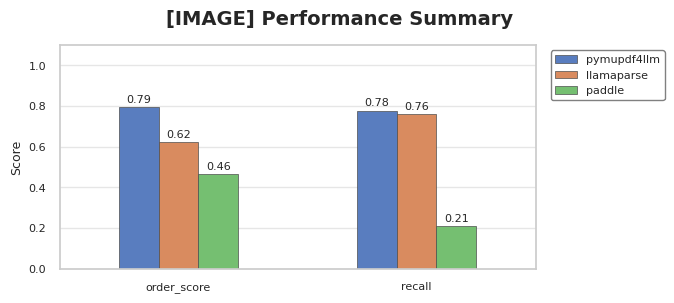

✅ Bar Chart Saved: /content/drive/MyDrive/ocr_eval/Results/eval_bar_image.png


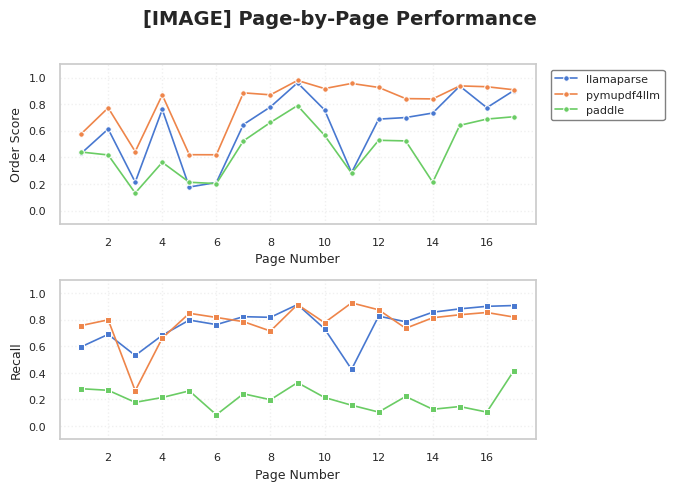

✅ Line Chart Saved (Y-Axis Fixed): /content/drive/MyDrive/ocr_eval/Results/eval_line_image.png


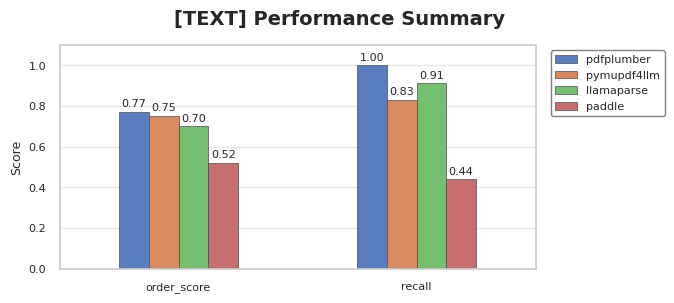

✅ Bar Chart Saved: /content/drive/MyDrive/ocr_eval/Results/eval_bar_text.png


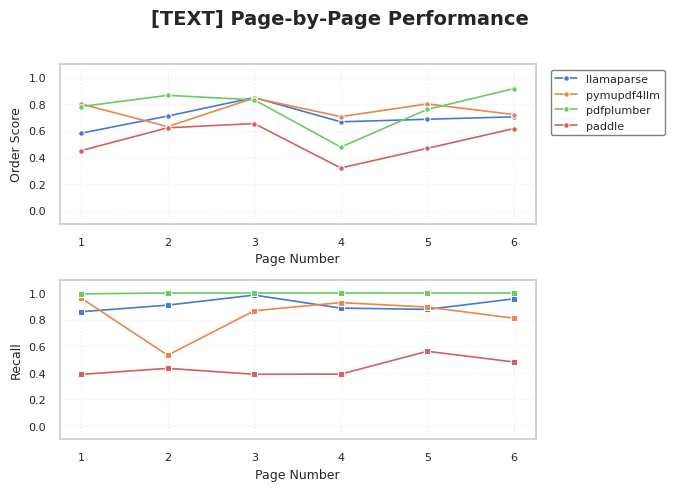

✅ Line Chart Saved (Y-Axis Fixed): /content/drive/MyDrive/ocr_eval/Results/eval_line_text.png


In [ ]:
#@title 시각화
# 1. 파일 경로 설정
results_dir = os.path.join(OUTPUT_ROOT, "Results")
summary_csv_path = os.path.join(results_dir, "parser_eval_summary.csv")
detail_csv_path = os.path.join(results_dir, "parser_eval_results.csv")

# 그래프 제외 파서
GLOBAL_EXCLUDE_PARSERS = ["upstage"]

# 그래프 크기 고정 (가로 7인치)
BAR_FIGSIZE = (7, 3.2)   # 바 그래프 (납작하게)
LINE_FIGSIZE = (7, 5.0)  # 라인 그래프 (적당한 높이)

# 폰트 및 스타일
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Noto Sans KR', 'Noto Sans CJK KR', 'Malgun Gothic', 'AppleGothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# 고해상도 저장 옵션
HIGH_DPI = 600

# 여백 강제 고정 값
MARGIN_LEFT = 0.10
MARGIN_RIGHT = 0.78
MARGIN_TOP = 0.85
MARGIN_BOTTOM_BAR = 0.15
MARGIN_BOTTOM_LINE = 0.10

# 폰트 사이즈
TITLE_SIZE = 14
LABEL_SIZE = 9
TICK_SIZE = 8
LEGEND_SIZE = 8

if os.path.exists(summary_csv_path) and os.path.exists(detail_csv_path):
    df_summary = pd.read_csv(summary_csv_path)
    df_detail = pd.read_csv(detail_csv_path)

    df_summary = df_summary[~df_summary["parser"].isin(GLOBAL_EXCLUDE_PARSERS)]
    df_detail = df_detail[~df_detail["parser"].isin(GLOBAL_EXCLUDE_PARSERS)]

    valid_parsers = df_summary[df_summary["f1"] > 0]["parser"].unique().tolist()
    print(f"✅ Valid Parsers: {valid_parsers}")

    # 그리드 스타일
    sns.set_theme(style="whitegrid", rc={"axes.edgecolor": ".8", "grid.color": ".9"})

    doc_types = df_summary["type"].unique()

    for doc_type in doc_types:
        sum_subset = df_summary[(df_summary["type"] == doc_type) & (df_summary["parser"].isin(valid_parsers))].copy()
        det_subset = df_detail[(df_detail["type"] == doc_type) & (df_detail["parser"].isin(valid_parsers))].copy()

        if sum_subset.empty: continue

        if doc_type == "image":
            img_exclude = ["pdfplumber"]
            sum_subset = sum_subset[~sum_subset["parser"].isin(img_exclude)]
            det_subset = det_subset[~det_subset["parser"].isin(img_exclude)]

        if sum_subset.empty:
            print(f"⚠️ [{doc_type}] 표시할 데이터가 없습니다.")
            continue

        # ==========================================================
        # [그래프 1] 평균 점수 비교 (Bar Chart)
        # ==========================================================
        df_melt = sum_subset.melt(
            id_vars=["parser"], value_vars=["order_score", "recall"],
            var_name="Metric", value_name="Score"
        )

        fig, ax = plt.subplots(1, 1, figsize=BAR_FIGSIZE)

        sns.barplot(
            data=df_melt, x="Metric", y="Score", hue="parser",
            palette="muted", edgecolor=".3", linewidth=0.5, width=0.5,
            ax=ax
        )

        fig.suptitle(f"[{doc_type.upper()}] Performance Summary", fontsize=TITLE_SIZE, fontweight='bold', y=0.96)

        # 바 차트는 0부터 시작하는 게 자연스러우므로 0~1.15 유지
        ax.set_ylim(0, 1.1)
        ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

        ax.set_xlabel("")
        ax.set_ylabel("Score", fontsize=LABEL_SIZE)
        ax.tick_params(axis='both', labelsize=TICK_SIZE)

        ax.legend(
            title=None, bbox_to_anchor=(1.02, 1), loc='upper left',
            fontsize=LEGEND_SIZE,
            frameon=True, edgecolor='gray', framealpha=1
        )

        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', padding=2, fontsize=TICK_SIZE)

        plt.subplots_adjust(left=MARGIN_LEFT, right=MARGIN_RIGHT, top=MARGIN_TOP, bottom=MARGIN_BOTTOM_BAR)

        save_bar_path = os.path.join(results_dir, f"eval_bar_{doc_type}.png")
        plt.savefig(save_bar_path, dpi=HIGH_DPI)
        plt.show()
        print(f"✅ Bar Chart Saved: {save_bar_path}")
        plt.close()

        # ==========================================================
        # [그래프 2] 페이지별 변화 (Line Chart)
        # ==========================================================
        fig, axes = plt.subplots(2, 1, figsize=LINE_FIGSIZE, sharex=False)

        fig.suptitle(f"[{doc_type.upper()}] Page-by-Page Performance", fontsize=TITLE_SIZE, fontweight='bold', y=0.96)

        # 1) Order Score
        sns.lineplot(
            data=det_subset, x="page", y="order_score", hue="parser",
            marker="o", markersize=4,
            ax=axes[0],
            linewidth=1.2,
            palette="muted"
        )
        axes[0].set_title("")
        axes[0].set_ylabel("Order Score", fontsize=LABEL_SIZE)

        # [수정] 라인 그래프 Y축 범위 -0.1 ~ 1.1로 강제 고정
        axes[0].set_ylim(-0.1, 1.1)
        axes[0].set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0]) # 눈금은 0~1만 표시

        axes[0].legend(
            title=None, bbox_to_anchor=(1.02, 1), loc='upper left',
            fontsize=LEGEND_SIZE, frameon=True, edgecolor='gray', framealpha=1
        )
        axes[0].grid(True, linestyle=':', alpha=0.6)
        axes[0].tick_params(labelsize=TICK_SIZE)
        axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        axes[0].set_xlabel("Page Number", fontsize=LABEL_SIZE)

        # 2) Recall
        sns.lineplot(
            data=det_subset, x="page", y="recall", hue="parser",
            marker="s", markersize=4,
            ax=axes[1],
            linewidth=1.2,
            palette="muted"
        )
        axes[1].set_title("")
        axes[1].set_ylabel("Recall", fontsize=LABEL_SIZE)

        # [수정] 라인 그래프 Y축 범위 -0.1 ~ 1.1로 강제 고정
        axes[1].set_ylim(-0.1, 1.1)
        axes[1].set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

        axes[1].set_xlabel("Page Number", fontsize=LABEL_SIZE)
        axes[1].legend().remove()
        axes[1].grid(True, linestyle=':', alpha=0.6)
        axes[1].tick_params(labelsize=TICK_SIZE)
        axes[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

        plt.subplots_adjust(left=MARGIN_LEFT, right=MARGIN_RIGHT, top=MARGIN_TOP, bottom=MARGIN_BOTTOM_LINE, hspace=0.35)

        save_line_path = os.path.join(results_dir, f"eval_line_{doc_type}.png")
        plt.savefig(save_line_path, dpi=HIGH_DPI)
        plt.show()
        print(f"✅ Line Chart Saved (Y-Axis Fixed): {save_line_path}")
        plt.close()

## LlamaParse

In [ ]:
# @title LlamaParse 그리드서치

PREMIUM_MODE_LIST           = [False, True]
OUTPUT_TABLES_HTML_LIST     = [False, True]
SKIP_DIAGONAL_TEXT_LIST     = [False, True]
DO_NOT_UNROLL_COLUMNS_LIST  = [False, True]
PRESERVE_LAYOUT_ALIGN_LIST  = [False, True]

param_configs = []
for (premium_mode,
     output_tables_as_HTML,
     skip_diagonal_text,
     do_not_unroll_columns,
     preserve_layout_alignment_across_pages) in product(
        PREMIUM_MODE_LIST,
        OUTPUT_TABLES_HTML_LIST,
        SKIP_DIAGONAL_TEXT_LIST,
        DO_NOT_UNROLL_COLUMNS_LIST,
        PRESERVE_LAYOUT_ALIGN_LIST,
    ):

    params = dict(
        premium_mode=premium_mode,
        output_tables_as_HTML=output_tables_as_HTML,
        skip_diagonal_text=skip_diagonal_text,
        do_not_unroll_columns=do_not_unroll_columns,
        preserve_layout_alignment_across_pages=preserve_layout_alignment_across_pages,
    )

    cfg_id = (
        f"pm{int(premium_mode)}"
        f"_html{int(output_tables_as_HTML)}"
        f"_diag{int(skip_diagonal_text)}"
        f"_col{int(do_not_unroll_columns)}"
        f"_align{int(preserve_layout_alignment_across_pages)}"
    )

    param_configs.append({"config_id": cfg_id, "params": params})


# =======================================
# 2. 평가 루프 (Upstage를 골든으로 사용)
# =======================================

rows = []

if not SAMPLE_PDF_PATH_LIST:
    print("⚠️ SAMPLE_PDF_PATH_LIST 비어 있음. 먼저 샘플 PDF 리스트를 설정하세요.")
else:
    for pdf_path in SAMPLE_PDF_PATH_LIST:
        pdf_name, file_type = get_pdf_info(pdf_path)
        print(f"\n==============================")
        print(f"📄 PDF: {pdf_name} ({file_type})")
        print(f"==============================")

        # --- Upstage 골든 로드 ---
        upstage_filename = f"upstage_{file_type}.jsonl"
        upstage_path = os.path.join(results_dir, upstage_filename)
        upstage_pages = load_pages_for_pdf(upstage_path, pdf_name)

        if not upstage_pages:
            print(f"⚠️ [{pdf_name}] 골든 데이터({upstage_filename}) 없음 → 스킵")
            continue

        # --- 파라미터 조합마다 LlamaParse 실행 ---
        for cfg in param_configs:
            cfg_id = cfg["config_id"]
            params = cfg["params"]

            print(f"  ▶ Config: {cfg_id}  | params={params}")

            start = time.time()
            try:
                parser = LlamaParse(
                    result_type="markdown",
                    language="ko",
                    verbose=False,
                    api_key=LLAMA_CLOUD_API_KEY,
                    **params,
                )
                docs = parser.load_data(pdf_path)
            except Exception as e:
                print(f"    🚨 LlamaParse 실패 ({cfg_id}): {e}")
                continue
            elapsed = time.time() - start
            print(f"    ⏱ 파싱 완료 ({elapsed:.2f}s, pages={len(docs)})")

            # 페이지별 텍스트 정리 (1-based index)
            pred_pages = {}
            for i, doc in enumerate(docs):
                page_idx = i + 1
                txt = doc.text or ""
                try:
                    clean_txt = normalize_whitespace(txt)
                except NameError:
                    clean_txt = txt.strip()
                pred_pages[page_idx] = clean_txt

            # 골든과 예측의 페이지 index 합집합 기준으로 평가
            all_page_indices = sorted(set(upstage_pages.keys()) | set(pred_pages.keys()))
            if not all_page_indices:
                print(f"    ⚠️ 페이지가 비어 있음. 스킵.")
                continue

            for page_idx in all_page_indices:
                gold_text = upstage_pages.get(page_idx, "")
                pred_text = pred_pages.get(page_idx, "")

                prec, rec, f1, order_score = calculate_metrics(gold_text, pred_text)

                row = {
                    "config_id": cfg_id,
                    "pdf_name": pdf_name,
                    "type": file_type,      # text / image
                    "page": page_idx,
                    "len_gold": len(gold_text),
                    "len_pred": len(pred_text),
                    "precision": prec,
                    "recall": rec,
                    "f1": f1,
                    "order_score": order_score,
                    # 파라미터 값도 같이 넣어두면 나중에 필터/피벗 분석 편함
                    **params,
                }
                rows.append(row)

# =======================================
# 3. 결과 요약 및 저장
# =======================================
df_detail = pd.DataFrame(rows)
summary = (
    df_detail
    .groupby(["type", "config_id"], as_index=False)[
        ["order_score", "f1", "precision", "recall"]
    ]
    .mean()
)

# 파라미터 컬럼 추가 (config_id 기준 첫 값)
param_cols = [
    "premium_mode",
    "output_tables_as_HTML",
    "skip_diagonal_text",
    "do_not_unroll_columns",
    "preserve_layout_alignment_across_pages",
]

param_info = (
    df_detail[["config_id"] + param_cols]
    .drop_duplicates("config_id")
)
summary = summary.merge(param_info, on="config_id", how="left")

# type → f1 내림차순 정렬
summary = summary.sort_values(by=["type", "f1"], ascending=[True, False])

# TEXT / IMAGE 요약 저장
summary_text  = summary[summary["type"] == "text"]
summary_image = summary[summary["type"] == "image"]

summary_text_path  = os.path.join(OUTPUT_ROOT, "TEXT",  "upstage", "llamaparse_param_eval_summary.csv")
summary_image_path = os.path.join(OUTPUT_ROOT, "IMAGE", "upstage", "llamaparse_param_eval_summary.csv")

summary_text.to_csv(summary_text_path,  index=False, encoding="utf-8-sig")
summary_image.to_csv(summary_image_path, index=False, encoding="utf-8-sig")

print(f"📁 TEXT 요약 결과 저장:  {summary_text_path}")
print(f"📁 IMAGE 요약 결과 저장: {summary_image_path}")

# 3-3. 옵션별 효과 분석 (True/False 평균 + 차이)
effect_rows = []
for doc_type in df_detail["type"].unique():  # text / image
    df_t = df_detail[df_detail["type"] == doc_type]

    for p in param_cols:
        agg = (
            df_t
            .groupby(p)[["f1", "order_score"]]
            .mean()
            .sort_index()
        )

        # bool 두 값(True/False) 있을 때만 delta 계산
        if agg.shape[0] == 2:
            false_val = agg.index[0]
            true_val  = agg.index[1]

            f1_false, order_false = agg.loc[false_val, ["f1", "order_score"]]
            f1_true, order_true   = agg.loc[true_val,  ["f1", "order_score"]]

            effect_rows.append({
                "type": doc_type,
                "param": p,
                "value_false": false_val,
                "f1_false": f1_false,
                "order_false": order_false,
                "value_true": true_val,
                "f1_true": f1_true,
                "order_true": order_true,
                "delta_f1_true_minus_false": f1_true - f1_false,
                "delta_order_true_minus_false": order_true - order_false,
            })

df_param_effect = pd.DataFrame(effect_rows)

# TEXT / IMAGE 옵션 효과 저장
effect_text  = df_param_effect[df_param_effect["type"] == "text"]
effect_image = df_param_effect[df_param_effect["type"] == "image"]

effect_text_path  = os.path.join(OUTPUT_ROOT, "TEXT",  "upstage", "llamaparse_param_effect_summary.csv")
effect_image_path = os.path.join(OUTPUT_ROOT, "IMAGE", "upstage", "llamaparse_param_effect_summary.csv")

effect_text.to_csv(effect_text_path,  index=False, encoding="utf-8-sig")
effect_image.to_csv(effect_image_path, index=False, encoding="utf-8-sig")

print(f"📁 TEXT 옵션 효과 요약 저장:  {effect_text_path}")
print(f"📁 IMAGE 옵션 효과 요약 저장: {effect_image_path}")




📄 PDF: split_image_test (image)
  ▶ Config: pm0_html0_diag0_col0_align0  | params={'premium_mode': False, 'output_tables_as_HTML': False, 'skip_diagonal_text': False, 'do_not_unroll_columns': False, 'preserve_layout_alignment_across_pages': False}
    ⏱ 파싱 완료 (16.55s, pages=17)
  ▶ Config: pm0_html0_diag0_col0_align1  | params={'premium_mode': False, 'output_tables_as_HTML': False, 'skip_diagonal_text': False, 'do_not_unroll_columns': False, 'preserve_layout_alignment_across_pages': True}
    ⏱ 파싱 완료 (103.16s, pages=17)
  ▶ Config: pm0_html0_diag0_col1_align0  | params={'premium_mode': False, 'output_tables_as_HTML': False, 'skip_diagonal_text': False, 'do_not_unroll_columns': True, 'preserve_layout_alignment_across_pages': False}
    ⏱ 파싱 완료 (15.76s, pages=17)
  ▶ Config: pm0_html0_diag0_col1_align1  | params={'premium_mode': False, 'output_tables_as_HTML': False, 'skip_diagonal_text': False, 'do_not_unroll_columns': True, 'preserve_layout_alignment_across_pages': True}
    ⏱ 파싱 완료 (

KeyError: "['hide_headers', 'hide_footers'] not in index"

In [ ]:
#@title llamapase 그리드 서치 결과 해석
# 해석 : Premium과 HTML 파라미터에서 유의미한 결과 보임
# 1. 저장된 파일 경로 설정 (위 코드와 경로 일치 확인)
summary_text_path  = os.path.join(OUTPUT_ROOT, "TEXT",  "upstage", "llamaparse_param_eval_summary.csv")
summary_image_path = os.path.join(OUTPUT_ROOT, "IMAGE", "upstage", "llamaparse_param_eval_summary.csv")

# 2. CSV 파일 로드 및 병합
loaded_dfs = [pd.read_csv(path) for path in [summary_text_path, summary_image_path]]
summary_loaded = pd.concat(loaded_dfs, ignore_index=True)

# 3. 파라미터 효과 분석 (Recall & Order Score: True - False)
effect_rows = []

# 분석할 파라미터 목록
param_cols = [
    "premium_mode",
    "output_tables_as_HTML",
    "skip_diagonal_text",
    "do_not_unroll_columns",
    "preserve_layout_alignment_across_pages",
]

# Type별(text/image), 파라미터별 루프
for t, sub in summary_loaded.groupby("type"):
    for p in param_cols:
        if p not in sub.columns:
            continue

        # 해당 파라미터(p)로 그룹핑하여 평균 계산
        agg = sub.groupby(p)[["recall", "order_score"]].mean()

        # True(1)와 False(0) 두 가지 값이 모두 존재할 때만 비교 수행
        # (csv 로드 시 boolean이 0/1 또는 False/True로 읽힐 수 있으므로 인덱스 정렬 후 사용)
        if agg.shape[0] == 2:
            levels = sorted(agg.index) # [False, True] 또는 [0, 1] 순서 보장
            false_val, true_val = levels[0], levels[1]

            rec_f = agg.loc[false_val, "recall"]
            rec_t = agg.loc[true_val,  "recall"]
            ord_f = agg.loc[false_val, "order_score"]
            ord_t = agg.loc[true_val,  "order_score"]

            effect_rows.append({
                "type": t,
                "param": p,
                # (값 * 100)을 하고 소수점 1자리까지 표시(.1f) 후 % 붙이기
                "RECALL_T_F": f"{(rec_t - rec_f) * 100:.1f}%",
                "ORDER_T_F":  f"{(ord_t - ord_f) * 100:.1f}%"
            })

# 4. 결과 저장
df_effect = pd.DataFrame(effect_rows).sort_values(["type", "param"]).reset_index(drop=True)

# 저장 경로 (통합 결과 폴더 또는 원하는 위치)
effect_path = os.path.join(llam_path, "llamaparse_param_eval_effect.csv")

df_effect.to_csv(effect_path, index=False, encoding="utf-8-sig")
display(df_effect)
print("-" * 80)
print(f"\n✅ 옵션별 효과 분석 완료 및 저장: {effect_path}")

,type,param,RECALL_T_F,ORDER_T_F
0,image,do_not_unroll_columns,0.1%,0.3%
1,image,output_tables_as_HTML,-21.6%,-8.2%
2,image,premium_mode,15.5%,4.6%
3,image,preserve_layout_alignment_across_pages,-1.7%,0.0%
4,image,skip_diagonal_text,0.2%,0.1%
5,text,do_not_unroll_columns,-0.5%,-0.2%
6,text,output_tables_as_HTML,-31.8%,-16.2%
7,text,premium_mode,-5.9%,-1.6%
8,text,preserve_layout_alignment_across_pages,0.1%,-0.1%
9,text,skip_diagonal_text,0.7%,0.1%


--------------------------------------------------------------------------------

✅ 옵션별 효과 분석 완료 및 저장: /content/drive/MyDrive/ocr_eval/Results/llamaparse/llamaparse_param_eval_effect.csv


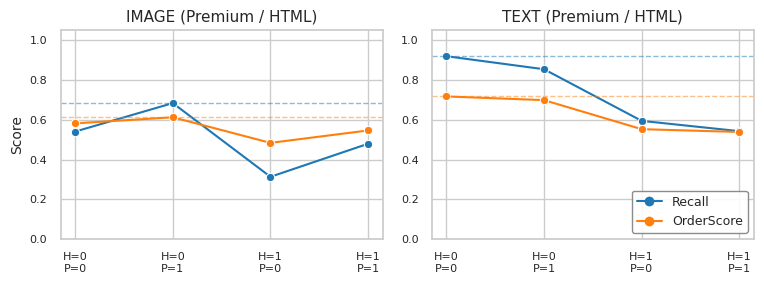

In [ ]:
#@title llamapase 그리드 서치 결과 시각화
summary_text_path  = os.path.join(OUTPUT_ROOT, "TEXT",  "upstage", "llamaparse_param_eval_summary.csv")
summary_image_path = os.path.join(OUTPUT_ROOT, "IMAGE", "upstage", "llamaparse_param_eval_summary.csv")

loaded_dfs = [pd.read_csv(path) for path in [summary_text_path, summary_image_path]]
summary = pd.concat(loaded_dfs, ignore_index=True)

long_df = (
    summary.groupby(["type", "premium_mode", "output_tables_as_HTML"], as_index=False)[["recall", "order_score"]]
    .mean()
    .assign(
        cond=lambda x: "H=" + x["output_tables_as_HTML"].astype(int).astype(str) +
                       "\nP=" + x["premium_mode"].astype(int).astype(str)
    )
    .sort_values("cond")
    .melt(
        id_vars=["type", "cond"],
        value_vars=["recall", "order_score"],
        var_name="metric",
        value_name="value"
    )
    .assign(type=lambda x: x["type"].str.upper()) # TYPE 대문자 변환
)

# 2. 그래프 생성
palette = {"recall": "tab:blue", "order_score": "tab:orange"}

g = sns.relplot(
    data=long_df, x="cond", y="value", hue="metric", col="type",
    kind="line", marker="o", palette=palette,
    height=3, aspect=1.3,
    facet_kws={"sharey": False, "despine": False},
    legend=False
)

# 3. 스타일 및 축 설정
g.set_titles("{col_name} (Premium / HTML)", size=11)
g.set(xlabel="", ylabel="")          # 기본 라벨 제거
g.axes[0, 0].set_ylabel("Score", fontsize=10) # 왼쪽만 Y축 라벨 부여

for ax in g.axes.flat:
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='both', labelsize=8)

# 4. 최대값 점선 표시
for (t, m), sub in long_df.groupby(["type", "metric"]):
    if t in g.axes_dict:
        g.axes_dict[t].axhline(sub["value"].max(), ls="--", lw=1, alpha=0.5, color=palette[m])

# 5. 커스텀 범례 (우측 그래프 내부)
legend_handles = [
    Line2D([0], [0], color=palette[key], marker='o', label=label)
    for key, label in [('recall', 'Recall'), ('order_score', 'OrderScore')]
]

g.axes[0, 1].legend(
    handles=legend_handles, loc='lower right', fontsize=9,
    frameon=True, framealpha=0.9, edgecolor="gray", facecolor="white"
)
llamparse_img_path = os.path.join(llam_path, "llamaparse_param_eval_img.png")
plt.savefig(llamparse_img_path)
plt.tight_layout()
plt.show()